In [8]:
# In[1] 配置 + 导入
import sys
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from pymbar import MBAR
from metabias.fht.gaussian import FunctionalHierarchicalTensorGaussian
from metabias.fht.sketch_gaussian import hier_tensor_sketch_gaussian



CASE_DIR = Path("/ocean/projects/mth210003p/lyuliyao/meta_bias/chignolin/1VII2/case0.5")

# MBAR / 模型参数
T = 300.0
kBT = 8.31446261815324e-3 * T  # kJ/mol
STRIDE = 50                    # 先快一点，想更精细可改 20 或 10
D_TRUE = 64
D_PAD = 64
L = 6
DEG = 10
EPS = 1#0.5
TAU_FACTOR = 10#0.5
ALPHA = 0.5
BLOCK_SIZE = 20000

# 1D FES 参数
NBINS = 120
OUT_DIR = CASE_DIR / "mbar_1d_marginal_T300K"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
# In[2] 工具函数
def parse_run_idx(p: Path) -> int:
    m = re.search(r"(\d+)$", p.name)
    if m is None:
        raise ValueError(f"bad run dir name: {p}")
    return int(m.group(1))

def parse_colvar_fields(colvar_path: Path):
    with open(colvar_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("#! FIELDS"):
                return line.strip().split()[2:]
            if line and not line.startswith("#"):
                break
    raise ValueError(f"no '#! FIELDS' in {colvar_path}")

def colvar_has_data_rows(colvar_path: Path) -> bool:
    with open(colvar_path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s and not s.startswith("#"):
                return True
    return False

def load_run_cv_and_bias(colvar_path: Path, d_true=9, stride=1):
    fields = parse_colvar_fields(colvar_path)
    dih_cols = [i for i, name in enumerate(fields) if name.startswith("p")]
    aux = []
    if len(dih_cols) < d_true:
        raise ValueError(f"{colvar_path}: dihedral cols < {d_true}")
    if "metad.bias" not in fields:
        raise ValueError(f"{colvar_path}: no metad.bias column")
    if "rg" in fields:
        aux.append(fields.index("rg"))
    if "e2e" in fields:
        aux.append(fields.index("e2e"))
    if "rmsd_ca" in fields:
        aux.append(fields.index("rmsd_ca"))

    bias_col = fields.index("metad.bias")
    dih_use = dih_cols[:d_true]
    dih_names = [fields[i] for i in dih_use]

    if not colvar_has_data_rows(colvar_path):
        return np.empty((0, d_true), dtype=np.float64), np.empty((0,), dtype=np.float64), dih_names

    data = np.loadtxt(colvar_path, comments="#", dtype=np.float64)
    if data.ndim == 1:
        data = data[None, :]
    if stride > 1:
        data = data[::stride]

    cv_scaled = data[:, dih_use] / np.pi   # 模型输入是 [-1,1]
    bias_kj = data[:, bias_col]
    return cv_scaled, bias_kj, dih_names, data[:,aux]

def softplus_stable(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)

def build_model_from_npz(npz_path: Path):
    obj = np.load(npz_path, allow_pickle=True)
    c = obj["c"].item()
    sigma = float(np.array(obj["gaussian_sigma"]).reshape(())) if "gaussian_sigma" in obj.files else 0.1
    center_spacing = float(np.array(obj["gaussian_center_spacing"]).reshape(())) if "gaussian_center_spacing" in obj.files else (2.0 / (2*DEG + 1))
    model = FunctionalHierarchicalTensorGaussian(
        d=D_PAD, L=L, deg=DEG, c=c, ghost_pt=[],
        sigma=sigma, center_spacing=center_spacing,
        domain=(-1.0, 1.0), pbc=True,
        whiten=True, whitening_regularization=1e-10,
        normalize=True
    )
    return model

def eval_reduced_bias(model, s_scaled):
    # 返回 u(s) = beta*V_bias = ALPHA * log(rho_eff)
    mask = list(range(D_TRUE + 1, D_PAD + 1))
    tau = TAU_FACTOR * EPS
    out = np.empty(s_scaled.shape[0], dtype=np.float64)

    for i0 in range(0, s_scaled.shape[0], BLOCK_SIZE):
        i1 = min(i0 + BLOCK_SIZE, s_scaled.shape[0])
        sb = s_scaled[i0:i1]
        sp = np.zeros((sb.shape[0], D_PAD), dtype=np.float64)
        sp[:, :D_TRUE] = sb

        rho_raw = model.evaluate_marginal(sp, mask=mask).astype(np.float64, copy=False)
        rho_raw = np.where(np.isfinite(rho_raw), rho_raw, 0.0)
        rho_eff = EPS + tau * softplus_stable(rho_raw / tau)
        out[i0:i1] = ALPHA * np.log(rho_eff)
    return out

In [10]:
# In[3] 构建 u_kn + 跑 MBAR + 得到无偏权重 w_n
run_dirs = sorted([p for p in CASE_DIR.glob("run*") if (p / "COLVAR").exists()], key=parse_run_idx)
run_idx = [parse_run_idx(p) for p in run_dirs]
print("runs:", run_idx[:5], "...", run_idx[-5:])

# 要求 run1..runN 连续
expected = list(range(1, run_idx[-1] + 1))
if run_idx != expected:
    raise RuntimeError(f"run index not contiguous.\nfound={run_idx[:10]}...")

n_states = run_idx[-1]  # state 0..n_states-1
cv_blocks = []
bias_blocks = []
sample_state_blocks = []
aux_blocks = []
N_k = np.zeros(n_states, dtype=np.int64)
run_slices = []
dih_names_global = None

cursor = 0
for rd in run_dirs:
    rid = parse_run_idx(rd)
    cv_scaled, bias_kj, dih_names,aux = load_run_cv_and_bias(rd / "COLVAR", d_true=D_TRUE, stride=STRIDE)
    print(cv_scaled.shape)
    print(aux.shape)
    if dih_names_global is None:
        dih_names_global = dih_names

    if cv_scaled.shape[0] == 0:
        print(f"run{rid}: COLVAR has no data rows, skipped")
        continue

    sampled_state = 0 if rid == 1 else (rid - 1)  # run(i) sampled with state i-1
    N_k[sampled_state] += cv_scaled.shape[0]

    cv_blocks.append(cv_scaled)
    bias_blocks.append(bias_kj)
    aux_blocks.append(aux)
    sample_state_blocks.append(np.full(cv_scaled.shape[0], sampled_state, dtype=np.int64))

    run_slices.append((rid, cursor, cursor + cv_scaled.shape[0]))
    cursor += cv_scaled.shape[0]

    print(f"run{rid}: frames={cv_scaled.shape[0]}, sampled_state={sampled_state}")

if not cv_blocks:
    raise RuntimeError("No non-empty COLVAR files found.")

s_all = np.vstack(cv_blocks)
bias_all_kj = np.concatenate(bias_blocks)
aux_all = np.vstack(aux_blocks)

sampled_state_all = np.concatenate(sample_state_blocks)
N_total = s_all.shape[0]

print("N_total =", N_total)
print("N_k shape =", N_k.shape, "sum =", N_k.sum())

# u_kn
u_kn = np.zeros((n_states, N_total), dtype=np.float64)  # state 0 是无偏置，u=0
for k in range(1, n_states):
    model_path = CASE_DIR / f"run{k}" / "c_save.npz"
    if not model_path.exists():
        raise FileNotFoundError(model_path)
    model = build_model_from_npz(model_path)
    u_kn[k, :] = eval_reduced_bias(model, s_all)#
    print(f"evaluated state {k} from run{k}/c_save.npz")

print("run MBAR ...")
mbar = MBAR(u_kn, N_k, verbose=True)
f_k = np.array(mbar.f_k)

# 兼容 pymbar v3/v4
if hasattr(mbar, "compute_free_energy_differences"):
    tmp = mbar.compute_free_energy_differences()
    Delta_f = tmp["Delta_f"]
    dDelta_f = tmp["dDelta_f"]
else:
    tmp = mbar.getFreeEnergyDifferences()
    Delta_f, dDelta_f = tmp[0], tmp[1]

# 目标无偏分布的样本权重
logNk = np.log(N_k.astype(np.float64))
log_denom = logsumexp((logNk + f_k)[:, None] - u_kn, axis=0)
logw = -log_denom
logw -= logw.max()
w = np.exp(logw)
w /= w.sum()

print("weights sum =", w.sum(), "ESS =", 1.0 / np.sum(w*w))

# 保存一个“CV + mbar_weight”的CSV（方便后续复用）
csv_out = OUT_DIR / "mbar_unbiased_samples_with_weights.csv"
header = ",".join([f"{n}_rad" for n in dih_names_global] + ["mbar_weight"])
arr_out = np.column_stack([s_all[:, :D_TRUE] * np.pi, w])
np.savetxt(csv_out, arr_out, delimiter=",", header=header, comments="")
print("saved:", csv_out)

runs: [1, 2, 3, 4, 5] ... [18, 19, 20, 21, 22]
(3197, 64)
(3197, 3)
run1: frames=3197, sampled_state=0
(1756, 64)
(1756, 3)
run2: frames=1756, sampled_state=1
(1089, 64)
(1089, 3)
run3: frames=1089, sampled_state=2
(1909, 64)
(1909, 3)
run4: frames=1909, sampled_state=3
(1947, 64)
(1947, 3)
run5: frames=1947, sampled_state=4
(1890, 64)
(1890, 3)
run6: frames=1890, sampled_state=5
(2271, 64)
(2271, 3)
run7: frames=2271, sampled_state=6
(2292, 64)
(2292, 3)
run8: frames=2292, sampled_state=7
(2419, 64)
(2419, 3)
run9: frames=2419, sampled_state=8
(2044, 64)
(2044, 3)
run10: frames=2044, sampled_state=9
(2823, 64)
(2823, 3)
run11: frames=2823, sampled_state=10
(2349, 64)
(2349, 3)
run12: frames=2349, sampled_state=11
(1990, 64)
(1990, 3)
run13: frames=1990, sampled_state=12
(2563, 64)
(2563, 3)
run14: frames=2563, sampled_state=13
(2454, 64)
(2454, 3)
run15: frames=2454, sampled_state=14
(2674, 64)
(2674, 3)
run16: frames=2674, sampled_state=15
(2419, 64)
(2419, 3)
run17: frames=2419, sam

/ocean/projects/mth210003p/lyuliyao/meta_bias/src/fht/gaussian.py:227: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  has_none_msg = msg1 == "None" or msg2 == "None"


evaluated state 1 from run1/c_save.npz
evaluated state 2 from run2/c_save.npz
evaluated state 3 from run3/c_save.npz
evaluated state 4 from run4/c_save.npz
evaluated state 5 from run5/c_save.npz
evaluated state 6 from run6/c_save.npz
evaluated state 7 from run7/c_save.npz
evaluated state 8 from run8/c_save.npz
evaluated state 9 from run9/c_save.npz
evaluated state 10 from run10/c_save.npz
evaluated state 11 from run11/c_save.npz
evaluated state 12 from run12/c_save.npz
evaluated state 13 from run13/c_save.npz
evaluated state 14 from run14/c_save.npz
evaluated state 15 from run15/c_save.npz
evaluated state 16 from run16/c_save.npz
evaluated state 17 from run17/c_save.npz
evaluated state 18 from run18/c_save.npz
evaluated state 19 from run19/c_save.npz
evaluated state 20 from run20/c_save.npz
evaluated state 21 from run21/c_save.npz
run MBAR ...
K (total states) = 22, total samples = 49423
N_k = 
[3197 1756 1089 1909 1947 1890 2271 2292 2419 2044 2823 2349 1990 2563
 2454 2674 2419 2300 

In [11]:
# In[4] 画不同 1D marginal FES（每个 CV 一张曲线）
def compute_1d_fes(x, weights, nbins=120):
    hist, edges = np.histogram(
        x, bins=nbins, range=(0, 10), weights=weights
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    prob = hist / hist.sum() if hist.sum() > 0 else np.zeros_like(hist)
    fes = np.full_like(prob, np.nan, dtype=np.float64)
    mask = prob > 0
    fes[mask] = -kBT * np.log(prob[mask])
    fes[mask] -= np.nanmin(fes[mask])
    return centers, prob, fes

# In[4] 画不同 1D marginal FES（每个 CV 一张曲线）
def compute_2d_fes(x,y, weights, nbins=120):
    hist, xedges,yedges = np.histogram2d(
        x,y, bins=nbins, weights=weights
    )
    centers_x = 0.5 * (xedges[:-1] + xedges[1:])
    centers_y = 0.5 * (yedges[:-1] + yedges[1:])
    prob = hist / hist.sum() if hist.sum() > 0 else np.zeros_like(hist)
    fes = np.full_like(prob, np.nan, dtype=np.float64)
    mask = prob > 0
    fes[mask] = -kBT * np.log(prob[mask])
    fes[mask] -= np.nanmin(fes[mask])
    return centers_x,centers_y, prob, fes



In [12]:
aux_all.shape

(49423, 3)

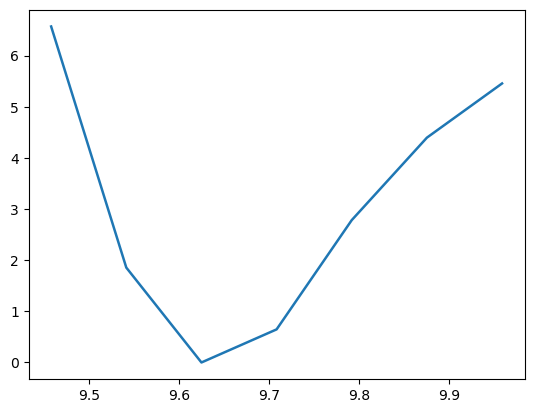

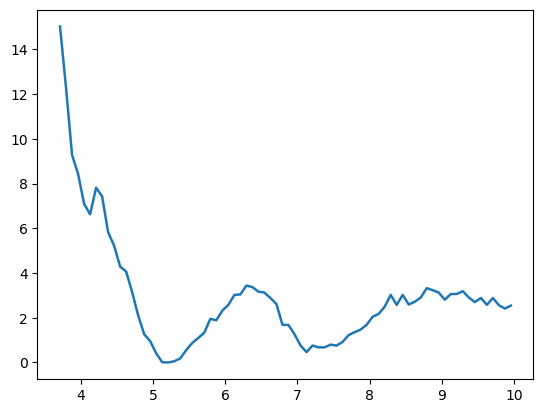

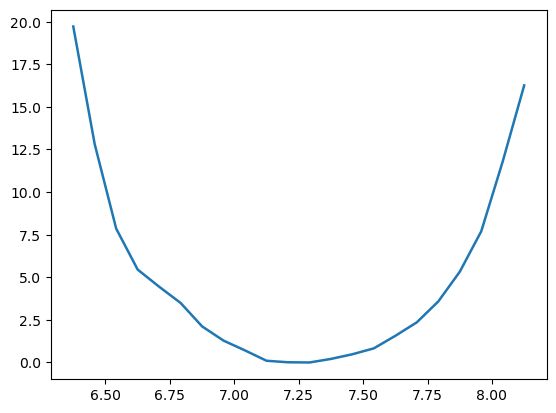

In [13]:
fig, axes = plt.subplots(1, 1)

centers, prob, fes = compute_1d_fes(aux_all[:,0]*10, np.ones_like(w), nbins=NBINS)

plt.plot(centers, fes, lw=1.8)
fig, axes = plt.subplots(1, 1)

centers, prob, fes = compute_1d_fes(aux_all[:,1]*10, np.ones_like(w), nbins=NBINS)

plt.plot(centers, fes, lw=1.8)

fig, axes = plt.subplots(1, 1)

centers, prob, fes = compute_1d_fes(aux_all[:,2]*10, np.ones_like(w), nbins=NBINS)

plt.plot(centers, fes, lw=1.8)
